In [42]:
#Importing dependencies
import tensorflow.keras as keras
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

In [43]:
#Opening .csv file
df = pd.read_csv("/users/imbahndu/Desktop/Columbia DBM/Smartwatch dataset_In progress/preprocessed/preprocessed_typing.csv")
df

,condition,patient_id,Accelerometer_X_mean,Accelerometer_X_std,Accelerometer_X_max,Accelerometer_X_min,Accelerometer_Y_mean,Accelerometer_Y_std,Accelerometer_Y_max,Accelerometer_Y_min,...,Gyroscope_Y_std,Gyroscope_Y_max,Gyroscope_Y_min,Gyroscope_Z_mean,Gyroscope_Z_std,Gyroscope_Z_max,Gyroscope_Z_min,task,wrist_LeftWrist,wrist_RightWrist
0,Healthy,1,-1.956550,2.215966,-0.665711,-1.863480,-1.385773,1.054774,0.148228,-1.635454,...,0.566004,1.396370,-0.741200,-3.041104,1.650079,3.319412,-2.718235,0,True,False
1,Healthy,1,-1.440854,1.455673,-0.550948,-1.017312,0.861733,0.812738,0.347888,-0.760231,...,0.473085,1.174377,-1.094204,2.632523,1.352064,2.244634,-3.044714,0,False,True
2,Healthy,1,-0.057320,0.000288,0.690811,0.169827,-0.335774,0.253703,0.579272,-2.261057,...,0.138340,0.289135,-1.127973,0.040293,0.002580,0.325232,-0.005535,1,True,False
3,Healthy,1,-0.417996,1.176585,0.510503,-0.917322,0.049310,1.215156,1.426583,-0.595149,...,1.078296,1.621335,-2.977478,0.145056,0.979674,2.271598,-2.037911,1,False,True
4,Healthy,1,0.040363,-0.561332,-0.419716,0.227308,-0.140380,-0.571669,-0.498113,0.532107,...,-0.655203,-0.735737,0.740464,-0.004524,-0.626584,-0.677071,0.557575,2,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7805,Parkinson's,469,0.079142,-0.703760,-0.677144,0.259101,-0.195320,-0.659775,-0.530905,0.619259,...,-0.725237,-0.857704,0.631301,-0.014677,-0.663613,-0.690555,0.764921,8,False,True
7806,Parkinson's,469,2.342317,1.199528,0.662420,-0.344564,0.929031,1.174975,0.217254,-1.192022,...,0.586592,0.667336,-0.309455,-1.552354,2.566972,2.020893,-2.391790,9,True,False
7807,Parkinson's,469,-2.303851,0.605052,-0.199139,-0.356784,1.537547,0.760961,0.144158,-0.223516,...,1.020072,1.064460,-0.964653,1.046335,2.113490,1.600687,-1.774930,9,False,True
7808,Parkinson's,469,0.275406,0.242516,-0.098475,-0.068806,-0.315676,1.319913,0.197179,-0.352881,...,0.965524,0.945067,-0.494665,-2.540505,2.227508,1.843224,-1.802734,10,True,False


In [44]:
#Convertoing boolean to string
import numpy as np

df["wrist_LeftWrist"] = df["wrist_LeftWrist"].astype("float64")
df["wrist_RightWrist"] = df["wrist_RightWrist"].astype("float64")
df["condition"] = df["condition"].replace({"Healthy": False, "Parkinson's": True})
df["condition"] = df["condition"].astype("float64")

df

/tmp/ipykernel_458969/846824527.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["condition"] = df["condition"].replace({"Healthy": False, "Parkinson's": True})


,condition,patient_id,Accelerometer_X_mean,Accelerometer_X_std,Accelerometer_X_max,Accelerometer_X_min,Accelerometer_Y_mean,Accelerometer_Y_std,Accelerometer_Y_max,Accelerometer_Y_min,...,Gyroscope_Y_std,Gyroscope_Y_max,Gyroscope_Y_min,Gyroscope_Z_mean,Gyroscope_Z_std,Gyroscope_Z_max,Gyroscope_Z_min,task,wrist_LeftWrist,wrist_RightWrist
0,0.0,1,-1.956550,2.215966,-0.665711,-1.863480,-1.385773,1.054774,0.148228,-1.635454,...,0.566004,1.396370,-0.741200,-3.041104,1.650079,3.319412,-2.718235,0,1.0,0.0
1,0.0,1,-1.440854,1.455673,-0.550948,-1.017312,0.861733,0.812738,0.347888,-0.760231,...,0.473085,1.174377,-1.094204,2.632523,1.352064,2.244634,-3.044714,0,0.0,1.0
2,0.0,1,-0.057320,0.000288,0.690811,0.169827,-0.335774,0.253703,0.579272,-2.261057,...,0.138340,0.289135,-1.127973,0.040293,0.002580,0.325232,-0.005535,1,1.0,0.0
3,0.0,1,-0.417996,1.176585,0.510503,-0.917322,0.049310,1.215156,1.426583,-0.595149,...,1.078296,1.621335,-2.977478,0.145056,0.979674,2.271598,-2.037911,1,0.0,1.0
4,0.0,1,0.040363,-0.561332,-0.419716,0.227308,-0.140380,-0.571669,-0.498113,0.532107,...,-0.655203,-0.735737,0.740464,-0.004524,-0.626584,-0.677071,0.557575,2,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7805,1.0,469,0.079142,-0.703760,-0.677144,0.259101,-0.195320,-0.659775,-0.530905,0.619259,...,-0.725237,-0.857704,0.631301,-0.014677,-0.663613,-0.690555,0.764921,8,0.0,1.0
7806,1.0,469,2.342317,1.199528,0.662420,-0.344564,0.929031,1.174975,0.217254,-1.192022,...,0.586592,0.667336,-0.309455,-1.552354,2.566972,2.020893,-2.391790,9,1.0,0.0
7807,1.0,469,-2.303851,0.605052,-0.199139,-0.356784,1.537547,0.760961,0.144158,-0.223516,...,1.020072,1.064460,-0.964653,1.046335,2.113490,1.600687,-1.774930,9,0.0,1.0
7808,1.0,469,0.275406,0.242516,-0.098475,-0.068806,-0.315676,1.319913,0.197179,-0.352881,...,0.965524,0.945067,-0.494665,-2.540505,2.227508,1.843224,-1.802734,10,1.0,0.0


In [45]:
#Balancing the class label with smote

#Defining features and labels 
y = df["condition"]
X = df.drop(columns = ["condition", "patient_id"])
from imblearn.over_sampling import SMOTE
from collections import Counter

print("Original class distribution:", Counter(y))

smote= SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Resampled class distribution:", Counter(y_resampled))
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size = 0.2, random_state = 42)

Original class distribution: Counter({1.0: 6072, 0.0: 1738})
Resampled class distribution: Counter({0.0: 6072, 1.0: 6072})


/users/imbahndu/.local/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [46]:
#Building up the nn layers

nn_model = keras.Sequential()

#Input layer 
input_layer = keras.layers.InputLayer(input_shape = (len(X_train.columns),))
nn_model.add(input_layer)

#Hidden layer 1
hidden_layer_1 = keras.layers.Dense(units = 128, activation="relu")
nn_model.add(hidden_layer_1)

#Hidden layer 2
hidden_layer_2 = keras.layers.Dense(units=64, activation="relu")
nn_model.add(hidden_layer_2)

#hidden layer 3
hidden_layer_3 = keras.layers.Dense(units=32, activation="relu")
nn_model.add(hidden_layer_3)
dropout = keras.layers.Dropout(0.2)
nn_model.add(dropout)

#extra hidden layer 
hidden_layer_5 = keras.layers.Dense(units=16, activation="relu")
nn_model.add(hidden_layer_5)
nn_model.add(keras.layers.Dropout(0.2))

#extra hidden layer 
hidden_layer_5 = keras.layers.Dense(units=8, activation="relu")
nn_model.add(hidden_layer_5)
nn_model.add(keras.layers.Dropout(0.2))

#hidden layer 4 / output 5
hidden_layer_4 = keras.layers.Dense(units=1, activation="sigmoid")
nn_model.add(hidden_layer_4)


#Summary
nn_model.summary()

/users/imbahndu/.local/lib/python3.9/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_26 (Dense)                │ (None, 128)            │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,593 (57.00 KB)

 Trainable params: 14,593 (57.00 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
#Defining the loss function  and optimizer
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)

optim = keras.optimizers.Adam(learning_rate=0.001)

 #Compiling the model
nn_model.compile(optimizer=optim, loss=loss_fn, metrics=["accuracy"])

In [48]:
#Fitting the model
num_epochs = 100
model = nn_model.fit(X_train, y_train, epochs=num_epochs, validation_split=0.2)

Epoch 1/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4968 - loss: 0.6958 - val_accuracy: 0.5100 - val_loss: 0.6891
Epoch 2/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5322 - loss: 0.6894 - val_accuracy: 0.5687 - val_loss: 0.6816
Epoch 3/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5563 - loss: 0.6812 - val_accuracy: 0.5790 - val_loss: 0.6672
Epoch 4/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5804 - loss: 0.6659 - val_accuracy: 0.6032 - val_loss: 0.6560
Epoch 5/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5828 - loss: 0.6640 - val_accuracy: 0.5908 - val_loss: 0.6529
Epoch 6/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6045 - loss: 0.6438 - val_accuracy: 0.6068 - val_loss: 0.6409
Epoch 7/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6273 - loss: 0.6374 - val_accuracy: 0.6227 - val_loss: 0.6272
Epoch 8/100
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6334 - loss: 0.6238 - val_accu

In [49]:
#Evaluating the model's accuracy and loss over time through visualizations
print(model.history.keys())
import matplotlib.pyplot as plt

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


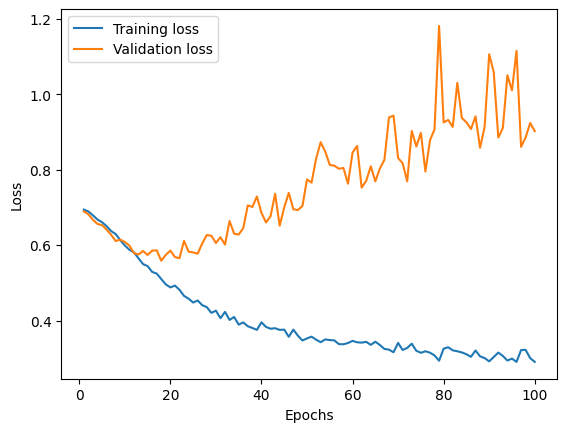

In [50]:
#Plotting loss 
plt.plot(range(1, num_epochs+1), model.history['loss'], label="Training loss")
plt.plot(range(1, num_epochs+1), model.history['val_loss'], label="Validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

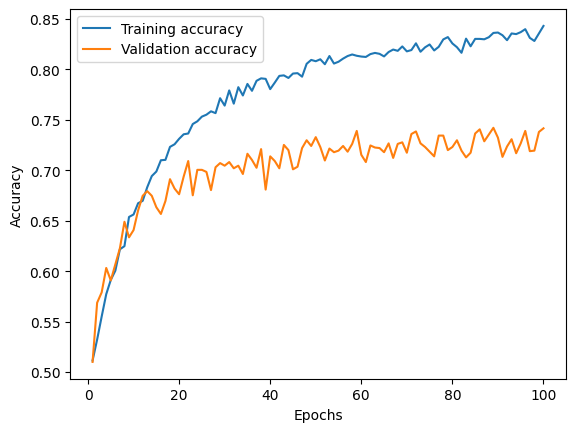

In [51]:
plt.plot(range(1, num_epochs+1), model.history['accuracy'], label="Training accuracy")
plt.plot(range(1, num_epochs+1), model.history['val_accuracy'], label="Validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [52]:
loss, accuracy = nn_model.evaluate(X_test,y_test)
print("Loss is ", loss)
print("Accuracy is", accuracy)

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7543 - loss: 0.8580
Loss is  0.9138893485069275
Accuracy is 0.7496912479400635
